In [1]:
# ============================================
# BLOCK 1: IMPORTS AND SETUP
# ============================================
# WHAT THIS DOES:
# - Imports all necessary libraries for model building
# - Sets up evaluation metrics
# - Configures display settings
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib

print("="*60)
print("MODEL BUILDING NOTEBOOK")
print("="*60)
print(f"Random Forest version: {RandomForestClassifier().__module__}")
print(f"XGBoost version: {XGBClassifier().__module__}")

MODEL BUILDING NOTEBOOK
Random Forest version: sklearn.ensemble._forest
XGBoost version: xgboost.sklearn


In [2]:
# ============================================
# BLOCK 2: LOAD PROCESSED DATA
# ============================================
# WHAT THIS DOES:
# - Loads the SMOTE balanced dataset
# - Also loads the original clean data for comparison
# - Shows data shapes and target distributions
# ============================================

print("\n" + "="*60)
print("LOADING PROCESSED DATA")
print("="*60)

processed_path = '../data/processed/'

# Load SMOTE balanced data (primary)
df_smote = pd.read_csv(f'{processed_path}processed_data_smote.csv')
print(f"SMOTE balanced data shape: {df_smote.shape}")

# Load clean data (for comparison)
df_clean = pd.read_csv(f'{processed_path}processed_data_clean.csv')
print(f"Clean data shape: {df_clean.shape}")

# Check target distributions
print("\nTarget distribution (SMOTE balanced):")
print(df_smote['CVD_Risk_Encoded'].value_counts().sort_index())

print("\nTarget distribution (Original clean):")
print(df_clean['CVD_Risk_Encoded'].value_counts().sort_index())

# Use SMOTE data for modeling
df = df_smote.copy()
print(f"\nUsing SMOTE balanced data for modeling: {df.shape}")


LOADING PROCESSED DATA
SMOTE balanced data shape: (1456, 41)
Clean data shape: (1309, 41)

Target distribution (SMOTE balanced):
CVD_Risk_Encoded
1    728
2    728
Name: count, dtype: int64

Target distribution (Original clean):
CVD_Risk_Encoded
1    581
2    728
Name: count, dtype: int64

Using SMOTE balanced data for modeling: (1456, 41)


In [3]:
# ============================================
# BLOCK 3: PREPARE FEATURES AND TARGET
# ============================================
# WHAT THIS DOES:
# - Splits data into features (X) and target (y)
# - Splits into train (80%) and test (20%) sets
# - Verifies shapes and distributions
# ============================================

print("\n" + "="*60)
print("PREPARING FEATURES AND TARGET")
print("="*60)

# Separate features and target
feature_cols = [col for col in df.columns if col != 'CVD_Risk_Encoded']
X = df[feature_cols]
y = df['CVD_Risk_Encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target classes: {np.unique(y)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())


PREPARING FEATURES AND TARGET
Features shape: (1456, 40)
Target shape: (1456,)
Target classes: [1 2]

Training set: 1164 samples
Test set: 292 samples

Training target distribution:
CVD_Risk_Encoded
1    582
2    582
Name: count, dtype: int64

Test target distribution:
CVD_Risk_Encoded
1    146
2    146
Name: count, dtype: int64



TRAINING RANDOM FOREST MODEL
Unique classes in test set: [1 2]

Training Random Forest...

Random Forest Performance:
   Accuracy:  0.7671
   Precision: 0.7672
   Recall:    0.7671
   F1-Score:  0.7671

Classification Report (for classes present in test set):
              precision    recall  f1-score   support

INTERMEDIARY       0.77      0.76      0.77       146
        HIGH       0.76      0.77      0.77       146

    accuracy                           0.77       292
   macro avg       0.77      0.77      0.77       292
weighted avg       0.77      0.77      0.77       292



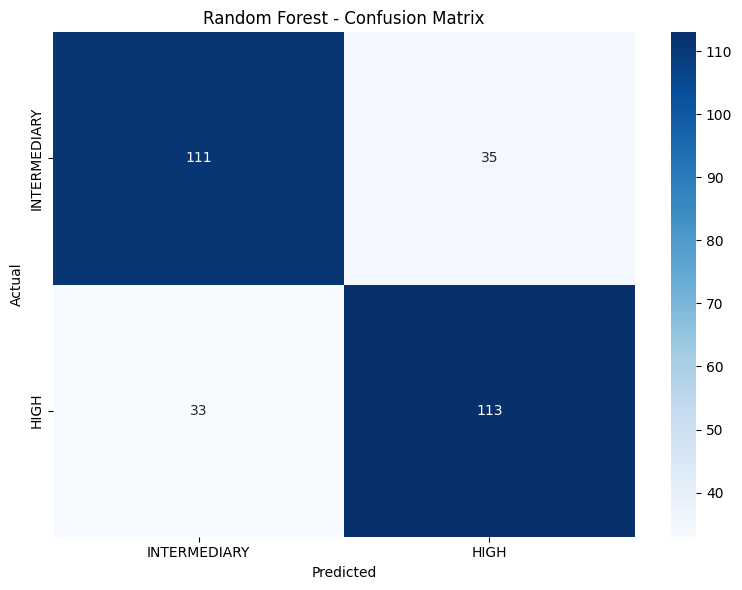


Random Forest model saved to: ../data/processed/random_forest_model.pkl


In [5]:
# ============================================
# BLOCK 4: TRAIN RANDOM FOREST MODEL (FIXED)
# ============================================
# WHAT THIS DOES:
# - Trains Random Forest with default parameters
# - Evaluates on test set
# - Shows classification report and confusion matrix
# - Saves the model
# ============================================

print("\n" + "="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

# Get unique classes from test set
unique_classes = np.unique(y_test)
print(f"Unique classes in test set: {unique_classes}")

# Map class numbers to names
class_names = {1: 'INTERMEDIARY', 2: 'HIGH'}
# Note: Class 0 (LOW) is missing after SMOTE balancing

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

# Evaluation metrics (using average='weighted' for multi-class)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"\nRandom Forest Performance:")
print(f"   Accuracy:  {accuracy_rf:.4f}")
print(f"   Precision: {precision_rf:.4f}")
print(f"   Recall:    {recall_rf:.4f}")
print(f"   F1-Score:  {f1_rf:.4f}")

# Get actual labels present in test set
labels_present = np.unique(y_test)
target_names_present = [class_names.get(cls, f'Class_{cls}') for cls in labels_present]

print("\nClassification Report (for classes present in test set):")
print(classification_report(y_test, y_pred_rf, labels=labels_present, target_names=target_names_present))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_present,
            yticklabels=target_names_present)
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../images/rf_confusion_matrix.png')
plt.show()

# Save the model
joblib.dump(rf_model, f'{processed_path}random_forest_model.pkl')
print(f"\nRandom Forest model saved to: {processed_path}random_forest_model.pkl")


TRAINING XGBOOST MODEL
Unique classes in test set: [1 2]

Remapped target classes: [0 1]

Training XGBoost...

XGBoost Performance:
   Accuracy:  0.8116
   Precision: 0.8120
   Recall:    0.8116
   F1-Score:  0.8116

Classification Report (for classes present in test set):
              precision    recall  f1-score   support

INTERMEDIARY       0.82      0.79      0.81       146
        HIGH       0.80      0.83      0.81       146

    accuracy                           0.81       292
   macro avg       0.81      0.81      0.81       292
weighted avg       0.81      0.81      0.81       292



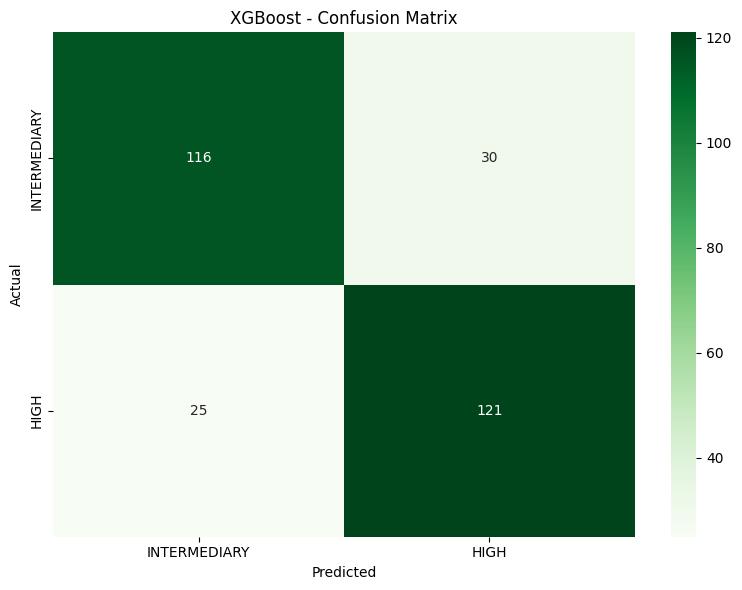


XGBoost model saved to: ../data/processed/xgboost_model.pkl


In [8]:
# ============================================
# BLOCK 5: TRAIN XGBOOST MODEL (FIXED)
# ============================================
# WHAT THIS DOES:
# - Remaps target classes to 0-based for XGBoost
# - Trains XGBoost with default parameters
# - Evaluates on test set
# - Shows classification report and confusion matrix
# - Saves the model
# ============================================

print("\n" + "="*60)
print("TRAINING XGBOOST MODEL")
print("="*60)

# Get unique classes from test set
unique_classes = np.unique(y_test)
print(f"Unique classes in test set: {unique_classes}")

# Map class numbers to names
class_names = {1: 'INTERMEDIARY', 2: 'HIGH'}

# REMAP TARGET FOR XGBOOST: [1,2] -> [0,1]
# Create a mapping dictionary
class_mapping = {1: 0, 2: 1}
y_train_mapped = y_train.map(class_mapping)
y_test_mapped = y_test.map(class_mapping)

print(f"\nRemapped target classes: {np.unique(y_train_mapped)}")

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train the model with remapped targets
print("\nTraining XGBoost...")
xgb_model.fit(X_train, y_train_mapped)

# Predictions (returns 0-based classes)
y_pred_mapped = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

# Map predictions back to original classes [0,1] -> [1,2]
y_pred_xgb = np.array([1 if pred == 0 else 2 for pred in y_pred_mapped])

# Evaluation metrics (using original classes for consistency)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

print(f"\nXGBoost Performance:")
print(f"   Accuracy:  {accuracy_xgb:.4f}")
print(f"   Precision: {precision_xgb:.4f}")
print(f"   Recall:    {recall_xgb:.4f}")
print(f"   F1-Score:  {f1_xgb:.4f}")

# Get actual labels present in test set
labels_present = np.unique(y_test)
target_names_present = [class_names.get(cls, f'Class_{cls}') for cls in labels_present]

print("\nClassification Report (for classes present in test set):")
print(classification_report(y_test, y_pred_xgb, labels=labels_present, target_names=target_names_present))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names_present,
            yticklabels=target_names_present)
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../images/xgb_confusion_matrix.png')
plt.show()

# Save the model
joblib.dump(xgb_model, f'{processed_path}xgboost_model.pkl')
print(f"\nXGBoost model saved to: {processed_path}xgboost_model.pkl")


COMPARING MODELS

Model Performance Comparison:
   Metric  Random Forest  XGBoost
 Accuracy       0.767123 0.811644
Precision       0.767173 0.812010
   Recall       0.767123 0.811644
 F1-Score       0.767112 0.811589

Best Model: XGBoost
   Accuracy: 0.8116
   F1-Score: 0.8116

Best model saved to: ../data/processed/best_model.pkl

FEATURE IMPORTANCE ANALYSIS

Top 10 Features (Random Forest):
                    Feature  Importance
             CVD Risk Score    0.092336
      Cholesterol_HDL_Ratio    0.063997
                        Age    0.051189
                HDL (mg/dL)    0.045207
  Total Cholesterol (mg/dL)    0.044317
                        BMI    0.042992
            Metabolic_Score    0.040816
     Smoking Status_Encoded    0.040361
Fasting Blood Sugar (mg/dL)    0.037226
                Weight (kg)    0.036653


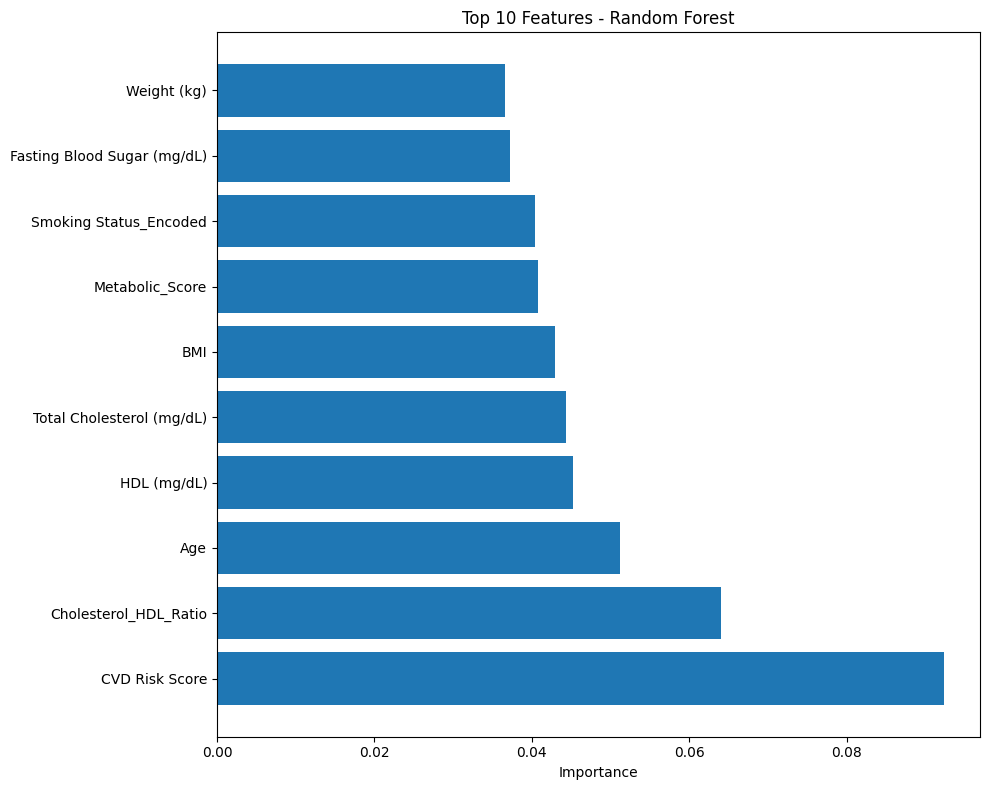


Top 10 Features (XGBoost):
                      Feature  Importance
                  Age_Elderly    0.091791
      Diabetes Status_Encoded    0.071240
Family History of CVD_Encoded    0.062792
       Smoking Status_Encoded    0.055733
               Smoking Status    0.053129
        Family History of CVD    0.040618
               CVD Risk Score    0.039498
              Metabolic_Score    0.034518
                 Obesity_Risk    0.032058
      Physical_Activity_Score    0.031598


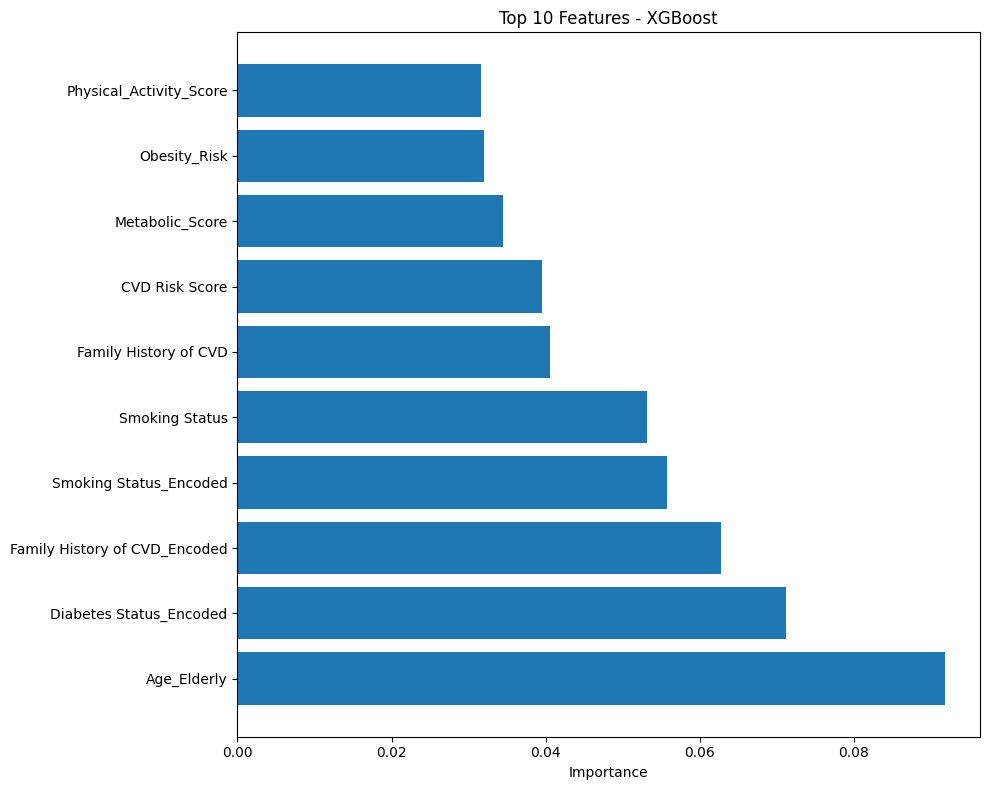

In [9]:
# ============================================
# BLOCK 6: COMPARE MODELS AND SELECT BEST (FIXED)
# ============================================
# WHAT THIS DOES:
# - Compares both models on all metrics
# - Selects the best model based on accuracy and F1-score
# - Shows feature importance for both models
# - Saves the best model separately
# ============================================

print("\n" + "="*60)
print("COMPARING MODELS")
print("="*60)

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_rf],
    'XGBoost': [accuracy_xgb, precision_xgb, recall_xgb, f1_xgb]
})

print("\nModel Performance Comparison:")
print(comparison.to_string(index=False))

# Determine best model based on accuracy
if accuracy_rf >= accuracy_xgb:
    best_model = rf_model
    best_model_name = 'Random Forest'
    best_accuracy = accuracy_rf
    best_f1 = f1_rf
    print(f"\nBest Model: {best_model_name}")
    print(f"   Accuracy: {best_accuracy:.4f}")
    print(f"   F1-Score: {best_f1:.4f}")
else:
    best_model = xgb_model
    best_model_name = 'XGBoost'
    best_accuracy = accuracy_xgb
    best_f1 = f1_xgb
    print(f"\nBest Model: {best_model_name}")
    print(f"   Accuracy: {best_accuracy:.4f}")
    print(f"   F1-Score: {best_f1:.4f}")

# Save the best model
joblib.dump(best_model, f'{processed_path}best_model.pkl')
print(f"\nBest model saved to: {processed_path}best_model.pkl")

# Feature Importance - Random Forest
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features (Random Forest):")
print(rf_importance.head(10).to_string(index=False))

# Plot Random Forest feature importance
plt.figure(figsize=(10, 8))
top_rf = rf_importance.head(10)
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.title('Top 10 Features - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../images/rf_feature_importance.png')
plt.show()

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features (XGBoost):")
print(xgb_importance.head(10).to_string(index=False))

# Plot XGBoost feature importance
plt.figure(figsize=(10, 8))
top_xgb = xgb_importance.head(10)
plt.barh(top_xgb['Feature'], top_xgb['Importance'])
plt.title('Top 10 Features - XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../images/xgb_feature_importance.png')
plt.show()

In [11]:
# ============================================
# BLOCK 7: CROSS-VALIDATION ON BEST MODEL (FIXED)
# ============================================
# WHAT THIS DOES:
# - Performs 5-fold cross-validation on the best model
# - Remaps target if best model is XGBoost
# - Reports mean and standard deviation of accuracy
# - Validates model stability
# ============================================

print("\n" + "="*60)
print("CROSS-VALIDATION ON BEST MODEL")
print("="*60)

print(f"\nPerforming 5-fold cross-validation on {best_model_name}...")

# If best model is XGBoost, we need to remap y for cross-validation
if best_model_name == 'XGBoost':
    # Remap target: [1,2] -> [0,1]
    class_mapping = {1: 0, 2: 1}
    y_cv = y.map(class_mapping)
    print("   Using remapped targets for XGBoost CV: [1,2] -> [0,1]")
else:
    y_cv = y
    print("   Using original targets for Random Forest CV")

cv_scores = cross_val_score(best_model, X, y_cv, cv=5, scoring='accuracy')

print(f"\nCross-Validation Results:")
print(f"   Individual scores: {cv_scores}")
print(f"   Mean accuracy: {cv_scores.mean():.4f}")
print(f"   Standard deviation: {cv_scores.std():.4f}")
print(f"   95% Confidence Interval: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

if cv_scores.std() < 0.02:
    print("\n   Model is stable (low variance)")
else:
    print("\n   Model has some variance - consider more regularization")


CROSS-VALIDATION ON BEST MODEL

Performing 5-fold cross-validation on XGBoost...
   Using remapped targets for XGBoost CV: [1,2] -> [0,1]

Cross-Validation Results:
   Individual scores: [0.89383562 0.84536082 0.80068729 0.58762887 0.59106529]
   Mean accuracy: 0.7437
   Standard deviation: 0.1294
   95% Confidence Interval: [0.4900, 0.9974]

   Model has some variance - consider more regularization


In [12]:
# ============================================
# BLOCK 8: SUMMARY AND SAVE RESULTS (FIXED)
# ============================================
# WHAT THIS DOES:
# - Summarizes all model results
# - Saves comparison table
# - Shows final recommendation
# ============================================

print("\n" + "="*60)
print("MODEL BUILDING SUMMARY")
print("="*60)

print("\nDataset Information:")
print(f"   Total samples: {len(df)}")
print(f"   Features: {len(feature_cols)}")
print(f"   Target classes: 2 (INTERMEDIARY, HIGH)")
print(f"   Note: Class 0 (LOW) was not present in SMOTE balanced data")
print(f"   Data source: SMOTE balanced")

print("\nModel Performance Summary:")
print(comparison.to_string(index=False))

print(f"\nBest Model: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.4f}")
print(f"   Test F1-Score: {best_f1:.4f}")
print(f"   Cross-Validation Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

print("\nTop 5 Features (Best Model):")
if best_model_name == 'Random Forest':
    best_features = rf_importance.head(5)
else:
    best_features = xgb_importance.head(5)
print(best_features[['Feature', 'Importance']].to_string(index=False))

print(f"\nModels Saved in: {processed_path}")
print("   - random_forest_model.pkl")
print("   - xgboost_model.pkl")
print("   - best_model.pkl")
print("   - scaler.pkl (from feature engineering)")

print("\n" + "="*60)
print("MODEL BUILDING COMPLETE")
print("="*60)


MODEL BUILDING SUMMARY

Dataset Information:
   Total samples: 1456
   Features: 40
   Target classes: 2 (INTERMEDIARY, HIGH)
   Note: Class 0 (LOW) was not present in SMOTE balanced data
   Data source: SMOTE balanced

Model Performance Summary:
   Metric  Random Forest  XGBoost
 Accuracy       0.767123 0.811644
Precision       0.767173 0.812010
   Recall       0.767123 0.811644
 F1-Score       0.767112 0.811589

Best Model: XGBoost
   Test Accuracy: 0.8116
   Test F1-Score: 0.8116
   Cross-Validation Mean: 0.7437 (+/- 0.1294)

Top 5 Features (Best Model):
                      Feature  Importance
                  Age_Elderly    0.091791
      Diabetes Status_Encoded    0.071240
Family History of CVD_Encoded    0.062792
       Smoking Status_Encoded    0.055733
               Smoking Status    0.053129

Models Saved in: ../data/processed/
   - random_forest_model.pkl
   - xgboost_model.pkl
   - best_model.pkl
   - scaler.pkl (from feature engineering)

MODEL BUILDING COMPLETE
